# Trayectoria — Sistema de Prevención de Deserción Estudiantil

**Flujo del proyecto:**
1. Carga y exploración de datos (EDA)
2. Preprocesamiento
3. Modelado predictivo (Fase 1): identificar alumnos en riesgo
4. Interpretabilidad (SHAP): entender qué variables pesan más
5. Clustering (Fase 2): perfilar a los alumnos en riesgo
6. Análisis de causas por perfil
7. Recomendaciones para la toma de decisiones
8. Conclusiones y guardado de artefactos

## 1. Setup: instalación e importación de librerías

In [5]:
# Instalación de librerías que no vienen por defecto en Colab
!pip install -q imbalanced-learn shap xgboost ucimlrepo

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, f1_score)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import shap

import joblib

# Semilla fija para reproducibilidad en todo el notebook
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 50)

## 2. Carga de datos

Usamos `ucimlrepo` para traer el dataset directo desde el repositorio (evita tener que subir el CSV manualmente cada vez).

In [7]:
from ucimlrepo import fetch_ucirepo

# id=697 corresponde a 'Predict Students' Dropout and Academic Success'
dataset = fetch_ucirepo(id=697)

X_raw = dataset.data.features.copy()
y_raw = dataset.data.targets.copy()

df = pd.concat([X_raw, y_raw], axis=1)

print(df.shape)
df.head()

(4424, 37)


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### 2.1 Diccionarios de decodificación

Estos mapeos vienen del paper original (Realinho et al., 2022) y de la documentación de UCI. Los usamos SOLO para el EDA (para que los gráficos y tablas se entiendan); para el modelado seguimos usando las columnas numéricas originales.

In [8]:
marital_status_map = {
    1: "Soltero(a)", 2: "Casado(a)", 3: "Viudo(a)",
    4: "Divorciado(a)", 5: "Unión de hecho", 6: "Separado(a) legalmente"
}

gender_map = {1: "Masculino", 0: "Femenino"}

attendance_map = {1: "Diurno", 0: "Vespertino"}

yes_no_map = {1: "Sí", 0: "No"}
yes_no_cols = [
    "Displaced", "Educational special needs", "Debtor",
    "Tuition fees up to date", "Scholarship holder", "International"
]

course_map = {
    1: "Tecnologías de Producción de Biocombustibles", 2: "Animación y Diseño Multimedia",
    3: "Trabajo Social (vespertino)", 4: "Agronomía", 5: "Diseño de Comunicación",
    6: "Enfermería Veterinaria", 7: "Ingeniería Informática", 8: "Equinicultura",
    9: "Gestión", 10: "Trabajo Social", 11: "Turismo", 12: "Enfermería",
    13: "Higiene Oral", 14: "Publicidad y Gestión de Marketing",
    15: "Periodismo y Comunicación", 16: "Educación Básica", 17: "Gestión (vespertino)"
}

application_mode_map = {
    1: "1ª fase - contingente general", 2: "Ordenanza Nº 612/93",
    3: "1ª fase - contingente especial (Azores)", 4: "Titulares de otros cursos superiores",
    5: "Ordenanza Nº 854-B/99", 6: "Estudiante internacional (grado)",
    7: "1ª fase - contingente especial (Madeira)", 8: "2ª fase - contingente general",
    9: "3ª fase - contingente general", 10: "Ordenanza Nº 533-A/99, item b2",
    11: "Ordenanza Nº 533-A/99, item b3", 12: "Mayor de 23 años", 13: "Transferencia",
    14: "Cambio de carrera", 15: "Titulares diploma especialización tecnológica",
    16: "Cambio de institución/carrera", 17: "Titulares diploma ciclo corto",
    18: "Cambio institución/carrera (internacional)"
}

target_map_readable = {"Dropout": "Deserción", "Enrolled": "Matriculado", "Graduate": "Graduado"}

# Nota: Mother's/Father's qualification y occupation tienen ~20-46 categorías cada una.
# Si necesitas decodificarlas para un gráfico puntual, dime cuál y te paso el diccionario
# específico; por ahora las dejamos numéricas ya que para el modelo no es necesario decodificarlas.

In [9]:
# Dataframe auxiliar SOLO para graficar/explorar de forma legible
df_eda = df.copy()
df_eda["Marital Status"] = df_eda["Marital Status"].map(marital_status_map)
df_eda["Gender"] = df_eda["Gender"].map(gender_map)
df_eda["Daytime/evening attendance"] = df_eda["Daytime/evening attendance"].map(attendance_map)
df_eda["Course"] = df_eda["Course"].map(course_map).fillna("Otro") # Se agregan los valores no mapeados a 'Otro'
df_eda["Application mode"] = df_eda["Application mode"].map(application_mode_map)
for col in yes_no_cols:
    df_eda[col] = df_eda[col].map(yes_no_map)
df_eda["Target"] = df_eda["Target"].map(target_map_readable)

df_eda.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,Soltero(a),Titulares diploma ciclo corto,5,Otro,Diurno,1,122.0,1,19,12,5,9,127.3,Sí,No,No,Sí,Masculino,No,20,No,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Deserción
1,Soltero(a),Titulares diploma especialización tecnológica,1,Otro,Diurno,1,160.0,1,1,3,3,3,142.5,Sí,No,No,No,Masculino,No,19,No,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduado
2,Soltero(a),1ª fase - contingente general,5,Otro,Diurno,1,122.0,1,37,37,9,9,124.8,Sí,No,No,No,Masculino,No,19,No,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Deserción
3,Soltero(a),Titulares diploma ciclo corto,2,Otro,Diurno,1,122.0,1,38,37,5,3,119.6,Sí,No,No,Sí,Femenino,No,20,No,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduado
4,Casado(a),NaN,1,Otro,Vespertino,1,100.0,1,37,38,9,9,141.5,No,No,No,Sí,Femenino,No,45,No,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduado


## 3. Análisis exploratorio (EDA)

In [10]:
# Valores nulos y tipos (el dataset original no trae nulos, pero siempre se verifica)
print(df.isnull().sum().sum(), "valores nulos totales")
df.info()

0 valores nulos totales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualific

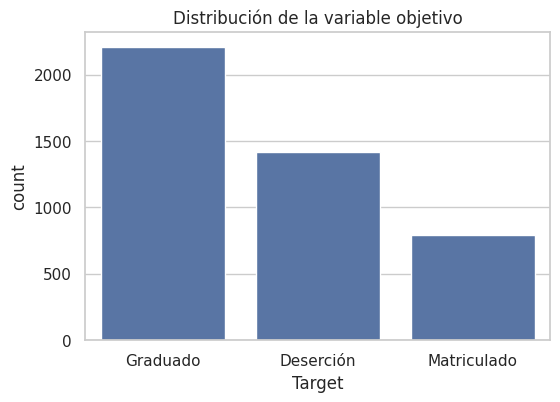

,proportion
Target,
Graduado,49.932188
Deserción,32.120253
Matriculado,17.947559


In [11]:
# Distribución de la variable objetivo — clave para saber que el problema está desbalanceado
plt.figure(figsize=(6,4))
sns.countplot(data=df_eda, x="Target", order=["Graduado","Deserción","Matriculado"])
plt.title("Distribución de la variable objetivo")
plt.show()

df_eda["Target"].value_counts(normalize=True) * 100

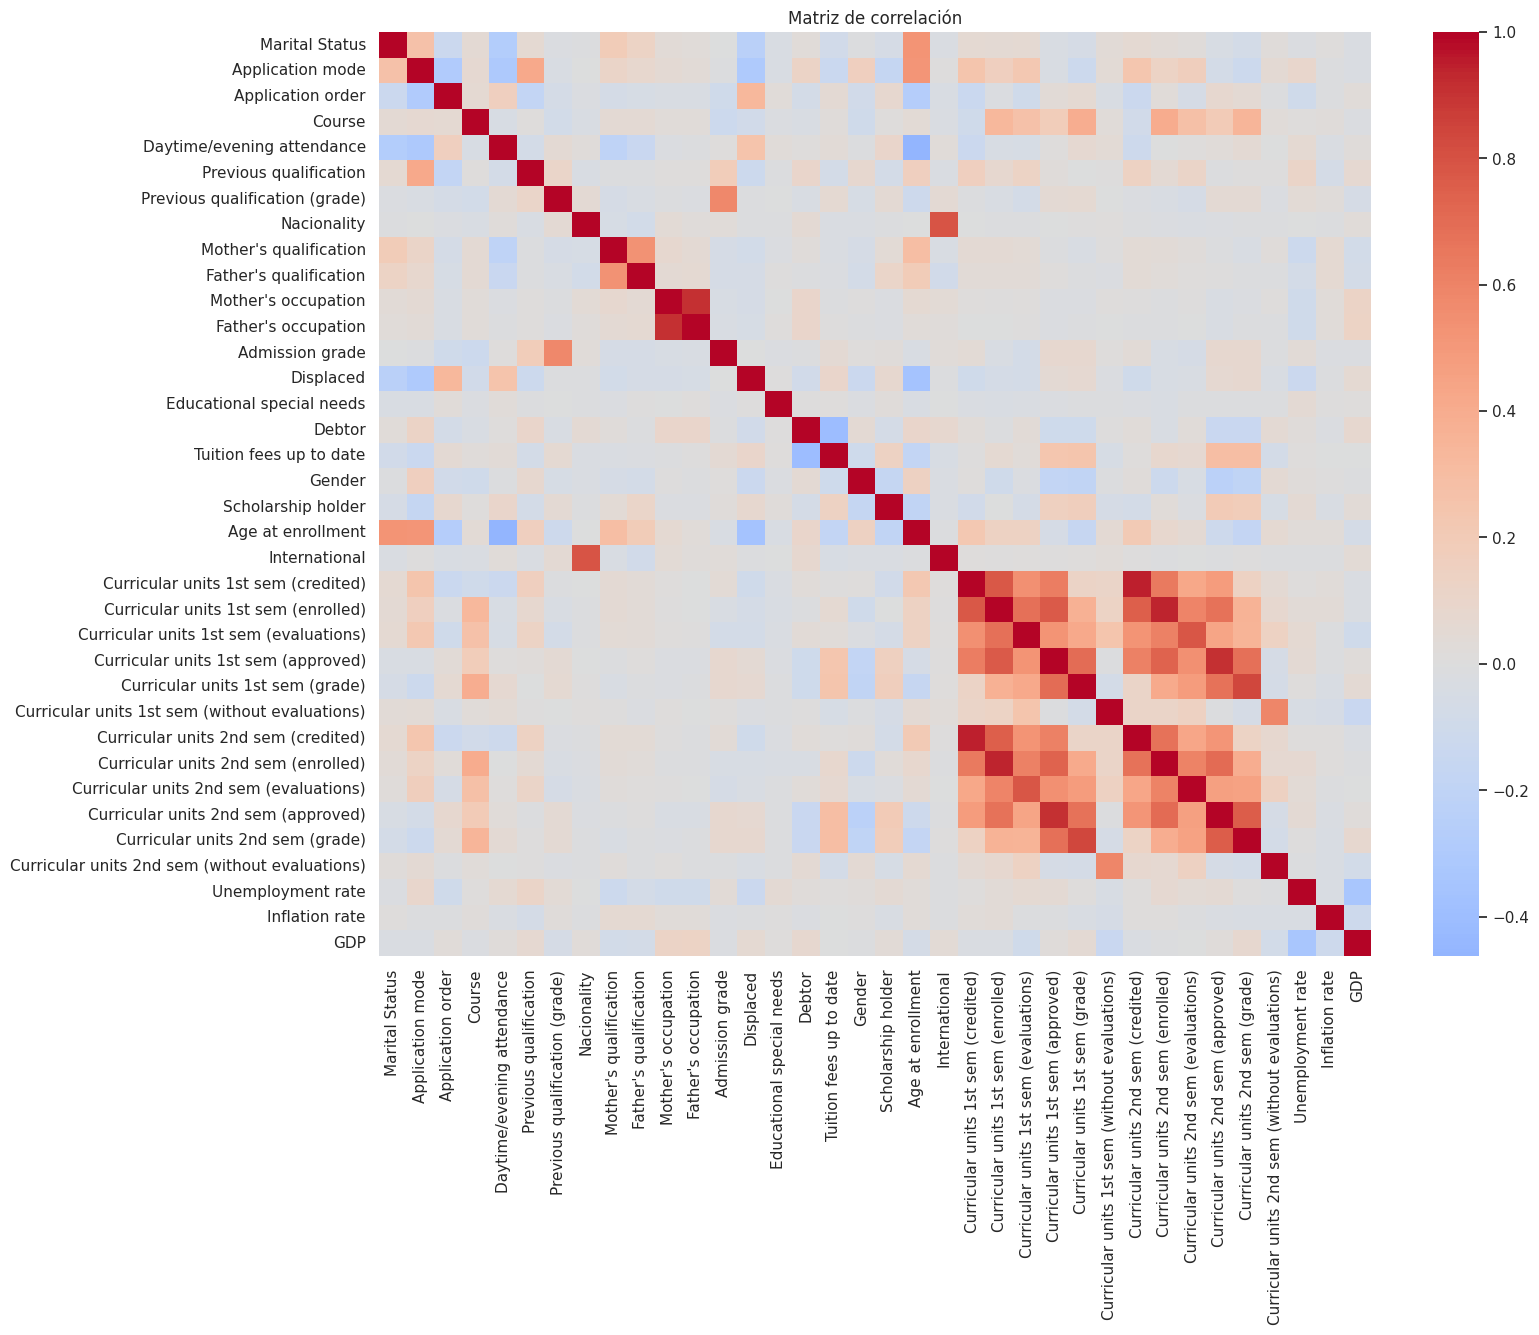

In [12]:
# Correlación entre variables numéricas — para detectar multicolinealidad antes de modelar
plt.figure(figsize=(16,12))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

### Correlaciones con la variable de deserción (Riesgo_desercion)

Analizando la matriz de correlación, podemos observar las siguientes relaciones con la variable `Riesgo_desercion` (que indica 1 para deserción y 0 para no deserción):

**Correlaciones Positivas (Mayor riesgo de deserción):**
*   **Curricular units 1st sem (without evaluations)**: Una correlación positiva significativa indica que los estudiantes que tienen unidades curriculares sin evaluar en el primer semestre tienden a tener un mayor riesgo de deserción.
*   **Debtor**: Los estudiantes que tienen deudas (`Debtor=1`) muestran una correlación positiva con la deserción.
*   **Age at enrollment**: Una edad mayor al matricularse también muestra una correlación positiva, sugiriendo que los estudiantes mayores podrían tener un mayor riesgo de deserción.

**Correlaciones Negativas (Menor riesgo de deserción):**
*   **Tuition fees up to date**: Los estudiantes que tienen sus aranceles al día (`Tuition fees up to date=1`) presentan una fuerte correlación negativa con la deserción, lo cual es esperable.
*   **Curricular units 1st sem (approved) y Curricular units 2nd sem (approved)**: Un mayor número de unidades curriculares aprobadas en ambos semestres se correlaciona negativamente con el riesgo de deserción, indicando que el rendimiento académico exitoso reduce la probabilidad de desertar.
*   **Curricular units 1st sem (grade) y Curricular units 2nd sem (grade)**: De manera similar, mejores calificaciones en el primer y segundo semestre están asociadas con un menor riesgo de deserción.
*   **Scholarship holder**: Ser beneficiario de una beca (`Scholarship holder=1`) tiene una correlación negativa con la deserción, lo que sugiere que el apoyo financiero puede ser un factor protector.

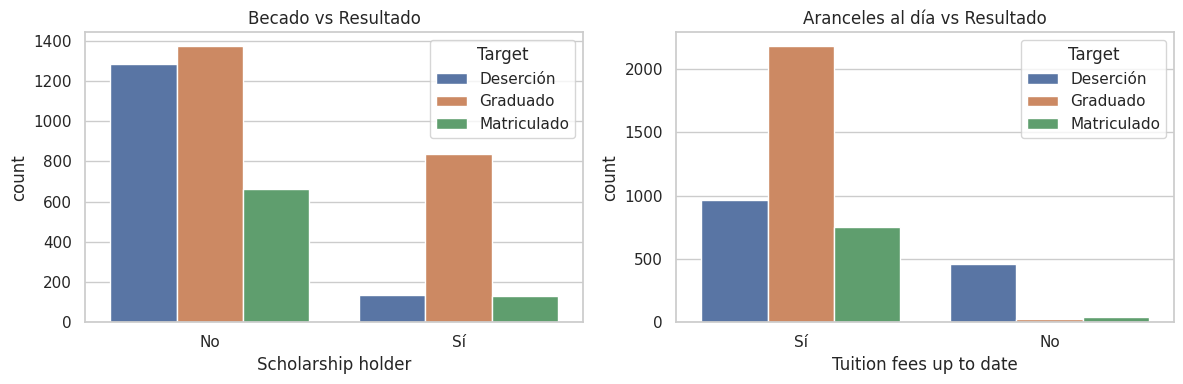

In [13]:
# Variables socioeconómicas vs deserción (ejemplo: beca y deuda)
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(data=df_eda, x="Scholarship holder", hue="Target", ax=axes[0])
axes[0].set_title("Becado vs Resultado")
sns.countplot(data=df_eda, x="Tuition fees up to date", hue="Target", ax=axes[1])
axes[1].set_title("Aranceles al día vs Resultado")
plt.tight_layout()
plt.show()

## 4. Preprocesamiento

Convertimos el problema a **binario** (Riesgo de deserción = Dropout vs No-Dropout). Esto es una decisión de diseño: para el objetivo de "identificar alumnos en riesgo" es más accionable que el problema multiclase original. Si más adelante se quiere distinguir "Enrolled" de "Graduate" como una segunda etapa, se puede hacer un segundo modelo.

In [14]:
df_model = df.copy()

# Variable binaria de riesgo: 1 = Dropout, 0 = No dropout (Enrolled o Graduate)
df_model["Riesgo_desercion"] = (df_model["Target"] == "Dropout").astype(int)
df_model = df_model.drop(columns=["Target"])

X = df_model.drop(columns=["Riesgo_desercion"])
y = df_model["Riesgo_desercion"]

print(y.value_counts(normalize=True))

Riesgo_desercion
0    0.678797
1    0.321203
Name: proportion, dtype: float64


In [15]:
# Split estratificado: mantiene la misma proporción de clases en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Escalado — necesario para Regresión Logística, no afecta a los modelos de árboles
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balanceo de clases SOLO sobre el set de entrenamiento (nunca sobre test, para no filtrar información)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Antes de SMOTE:", y_train.value_counts().to_dict())
print("Después de SMOTE:", y_train_bal.value_counts().to_dict())

Antes de SMOTE: {0: 2402, 1: 1137}
Después de SMOTE: {1: 2402, 0: 2402}


## 5. Modelado predictivo (Fase 1): identificar alumnos en riesgo

Entrenamos 3 modelos y comparamos. La métrica más importante aquí es el **recall de la clase Dropout** (no queremos dejar pasar alumnos en riesgo real) y el **F1**, más que el accuracy general (que puede engañar por el desbalance).

In [16]:
results = {}

def evaluar_modelo(nombre, modelo, X_te, y_te):
    y_pred = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]
    print(f"\n=== {nombre} ===")
    print(classification_report(y_te, y_pred, target_names=["No deserta", "Deserta"]))
    auc = roc_auc_score(y_te, y_proba)
    print(f"ROC-AUC: {auc:.3f}")
    results[nombre] = {
        "f1_deserta": f1_score(y_te, y_pred, pos_label=1),
        "roc_auc": auc,
        "modelo": modelo
    }
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, display_labels=["No deserta","Deserta"])
    plt.title(nombre)
    plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Regresión Logística ===
              precision    recall  f1-score   support

  No deserta       0.90      0.88      0.89       601
     Deserta       0.76      0.80      0.78       284

    accuracy                           0.86       885
   macro avg       0.83      0.84      0.84       885
weighted avg       0.86      0.86      0.86       885

ROC-AUC: 0.911


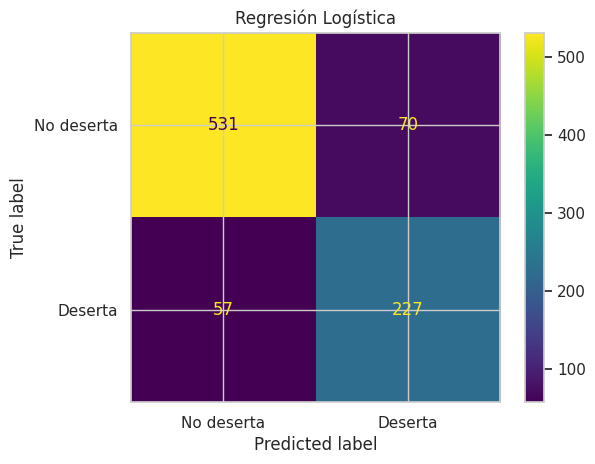

In [17]:
# Baseline: Regresión Logística
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_bal, y_train_bal)
evaluar_modelo("Regresión Logística", log_reg, X_test, y_test)


=== Random Forest ===
              precision    recall  f1-score   support

  No deserta       0.90      0.93      0.92       601
     Deserta       0.85      0.79      0.82       284

    accuracy                           0.89       885
   macro avg       0.88      0.86      0.87       885
weighted avg       0.89      0.89      0.89       885

ROC-AUC: 0.930


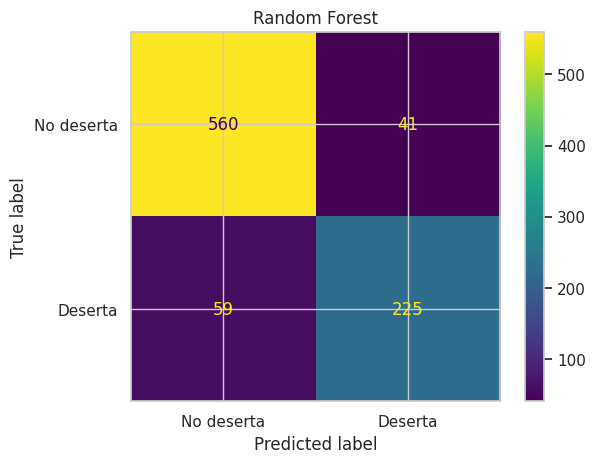

In [18]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
evaluar_modelo("Random Forest", rf, X_test, y_test)


=== XGBoost ===
              precision    recall  f1-score   support

  No deserta       0.90      0.93      0.91       601
     Deserta       0.83      0.79      0.81       284

    accuracy                           0.88       885
   macro avg       0.87      0.86      0.86       885
weighted avg       0.88      0.88      0.88       885

ROC-AUC: 0.931


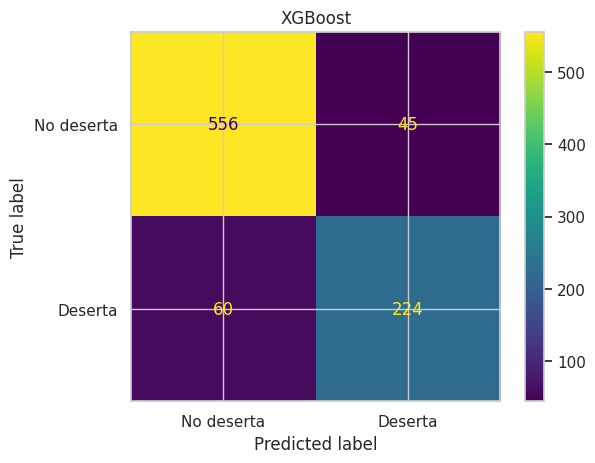

In [19]:
# XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    random_state=RANDOM_STATE, eval_metric="logloss"
)
xgb_clf.fit(X_train_bal, y_train_bal)
evaluar_modelo("XGBoost", xgb_clf, X_test, y_test)

In [20]:
# Comparación final de modelos
comparacion = pd.DataFrame({
    nombre: {"F1 (Deserta)": r["f1_deserta"], "ROC-AUC": r["roc_auc"]}
    for nombre, r in results.items()
}).T.sort_values("F1 (Deserta)", ascending=False)

comparacion

,F1 (Deserta),ROC-AUC
Random Forest,0.818182,0.929709
XGBoost,0.810127,0.930603
Regresión Logística,0.781411,0.910982


In [21]:
# Seleccionamos el mejor modelo automáticamente según F1 de la clase Deserta
mejor_nombre = comparacion.index[0]
mejor_modelo = results[mejor_nombre]["modelo"]
print(f"Mejor modelo: {mejor_nombre}")

Mejor modelo: Random Forest


## 6. Interpretabilidad con SHAP

Esto nos dice qué variables pesan más en la predicción de riesgo, y sienta la base para el perfilado (Fase 2).

/tmp/ipykernel_3135/2687883043.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_plot, X_test, show=True)
/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


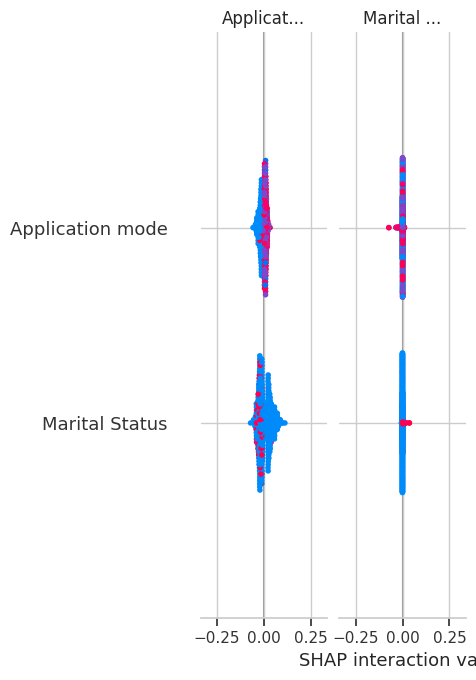

In [22]:
# SHAP funciona directo con modelos basados en árboles (RF, XGBoost).
explainer = shap.TreeExplainer(mejor_modelo)
shap_values = explainer.shap_values(X_test)

# Si el output es una lista (algunos modelos binarios devuelven 2 arrays), tomamos la clase 1
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

shap.summary_plot(shap_values_plot, X_test, show=True)

/tmp/ipykernel_3135/2247165541.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_plot, X_test, plot_type="bar", show=True)
/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


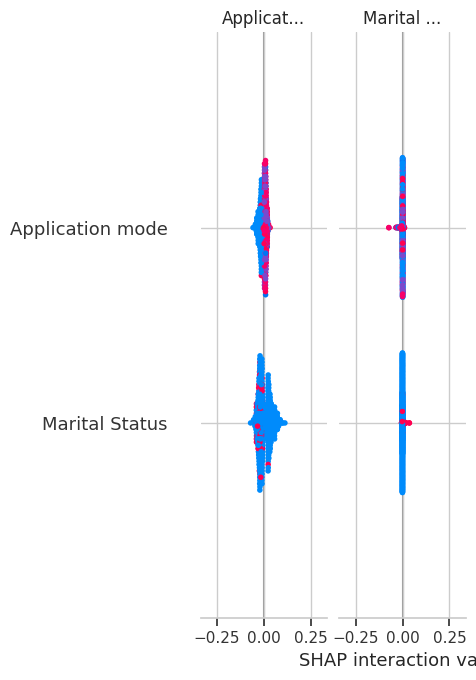

In [23]:
# Importancia global de variables (barra) — útil para el informe
shap.summary_plot(shap_values_plot, X_test, plot_type="bar", show=True)

### Explicación de los gráficos SHAP

Los gráficos SHAP (SHapley Additive exPlanations) nos ayudan a entender cómo cada variable contribuye a la predicción individual del modelo y, a nivel global, cuáles son las variables más importantes para el modelo.

**1. Gráfico de resumen (Summary Plot - primer gráfico SHAP):**

*   **Eje Y (izquierda):** Muestra todas las variables del modelo, ordenadas de la más importante (arriba) a la menos importante (abajo).
*   **Eje X (horizontal):** Representa el valor SHAP de cada variable. Un valor SHAP positivo significa que la variable empuja la predicción hacia un mayor riesgo de deserción, mientras que un valor negativo empuja la predicción hacia un menor riesgo de deserción.
*   **Puntos de colores:** Cada punto es una instancia (un alumno) y su color indica el valor de la característica para ese alumno:
    *   **Rojo:** Generalmente indica un valor alto de la variable (ej. `Age at enrollment` alto).
    *   **Azul:** Generalmente indica un valor bajo de la variable (ej. `Age at enrollment` bajo).

**¿Cómo se interpreta?**

Por ejemplo, si observamos la variable `Curricular units 1st sem (approved)`:
*   Vemos puntos azules a la derecha (valores SHAP positivos) y puntos rojos a la izquierda (valores SHAP negativos). Esto significa que **tener pocas unidades aprobadas en el primer semestre (azul oscuro) aumenta el riesgo de deserción**, mientras que **tener muchas unidades aprobadas (rojo) reduce el riesgo**.
*   Para `Tuition fees up to date`:
    *   Los puntos rojos (valores altos, es decir, aranceles al día = 1) se agrupan a la izquierda (valores SHAP negativos), indicando que tener los aranceles al día reduce el riesgo de deserción.
    *   Los puntos azules (valores bajos, es decir, aranceles no al día = 0) se agrupan a la derecha (valores SHAP positivos), indicando que no tener los aranceles al día aumenta el riesgo de deserción.

**2. Gráfico de barras (Bar Plot - segundo gráfico SHAP):**

Este gráfico es una versión simplificada del summary plot. Muestra la **importancia media absoluta** de cada variable. Es decir, resume cuánto impacta en promedio cada variable en la magnitud de la predicción (sin importar si empuja hacia arriba o hacia abajo). Es útil para tener una visión rápida de las variables más influyentes a nivel global del modelo.

En resumen, los SHAP values nos permiten ver no solo qué variables son importantes, sino también la dirección y magnitud de su impacto en la predicción de deserción, tanto para alumnos individuales como para el conjunto del modelo.

## 7. Perfilado de alumnos en riesgo (Fase 2): Clustering

Filtramos solo a los alumnos que el modelo predice como en riesgo, y los agrupamos según sus características. Esto responde a: "de los alumnos en riesgo, ¿qué tipos de perfiles existen?"

In [24]:
# Predecimos riesgo sobre TODO el dataset (no solo test) para tener más alumnos a perfilar
X_full_scaled = scaler.transform(X) if mejor_nombre == "Regresión Logística" else X
proba_riesgo = mejor_modelo.predict_proba(X_full_scaled)[:, 1]

df_model["proba_riesgo"] = proba_riesgo

# Umbral de riesgo: puedes ajustar este valor según qué tan conservador quieras ser
UMBRAL_RIESGO = 0.5
en_riesgo = df_model[df_model["proba_riesgo"] >= UMBRAL_RIESGO].copy()

print(f"Alumnos identificados en riesgo: {len(en_riesgo)} de {len(df_model)}")

Alumnos identificados en riesgo: 1403 de 4424


In [25]:
# Seleccionamos variables relevantes para el clustering (evitamos incluir el target y probas)
cols_cluster = [
    "Age at enrollment", "Scholarship holder", "Debtor", "Tuition fees up to date",
    "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)",
    "Displaced", "Unemployment rate", "Mother's qualification", "Father's qualification"
]

X_cluster = en_riesgo[cols_cluster].copy()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

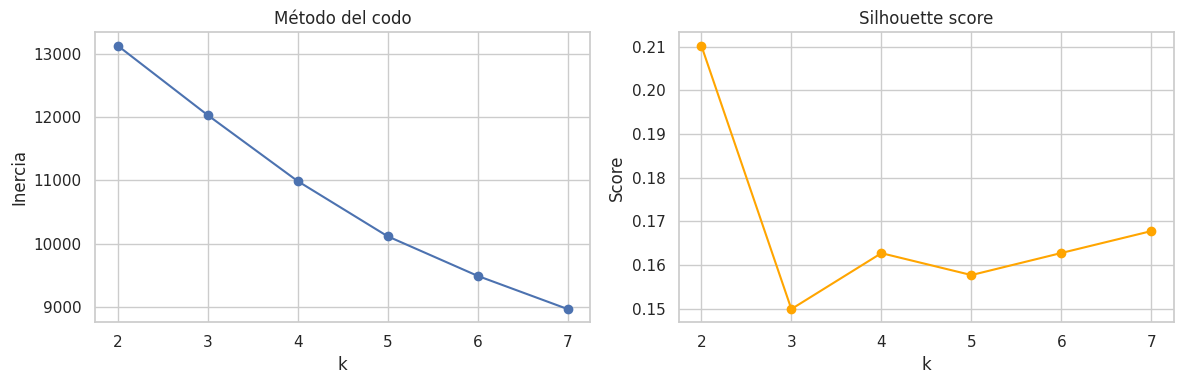

In [26]:
# Método del codo + silhouette score para elegir el número óptimo de clusters
inertias = []
silhouettes = []
rango_k = range(2, 8)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(list(rango_k), inertias, marker="o")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inercia")

axes[1].plot(list(rango_k), silhouettes, marker="o", color="orange")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

In [27]:
# Ajusta este valor según el gráfico anterior (donde se estabiliza la inercia
# y el silhouette es razonablemente alto)
K_OPTIMO = 4

kmeans_final = KMeans(n_clusters=K_OPTIMO, random_state=RANDOM_STATE, n_init=10)
en_riesgo["cluster"] = kmeans_final.fit_predict(X_cluster_scaled)

en_riesgo["cluster"].value_counts()

,count
cluster,
3,559
0,366
2,353
1,125


## 8. Análisis de causas por perfil

Para cada cluster, comparamos las medias de las variables clave contra el promedio general de los alumnos en riesgo. Esto ayuda a nombrar cada perfil de forma interpretable (ej. "riesgo económico", "bajo rendimiento académico", etc.).

In [28]:
perfil_clusters = en_riesgo.groupby("cluster")[cols_cluster].mean().round(2)
promedio_general = en_riesgo[cols_cluster].mean().round(2)

perfil_clusters.loc["Promedio general"] = promedio_general
perfil_clusters

,Age at enrollment,Scholarship holder,Debtor,Tuition fees up to date,Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Displaced,Unemployment rate,Mother's qualification,Father's qualification
cluster,,,,,,,,,,,,
0,31.75,0.01,0.20,0.59,0.54,2.83,0.13,1.03,0.30,11.42,33.47,33.80
1,21.98,1.00,0.26,0.76,3.20,9.09,2.34,7.09,0.64,11.48,21.37,23.26
2,22.84,0.00,0.17,0.70,0.68,3.08,0.05,0.41,0.52,12.05,8.60,11.96
3,25.41,0.00,0.27,0.68,4.63,12.16,3.95,12.03,0.49,11.43,20.69,21.91
Promedio general,26.11,0.09,0.23,0.67,2.44,7.17,1.83,5.80,0.46,11.59,21.04,22.63


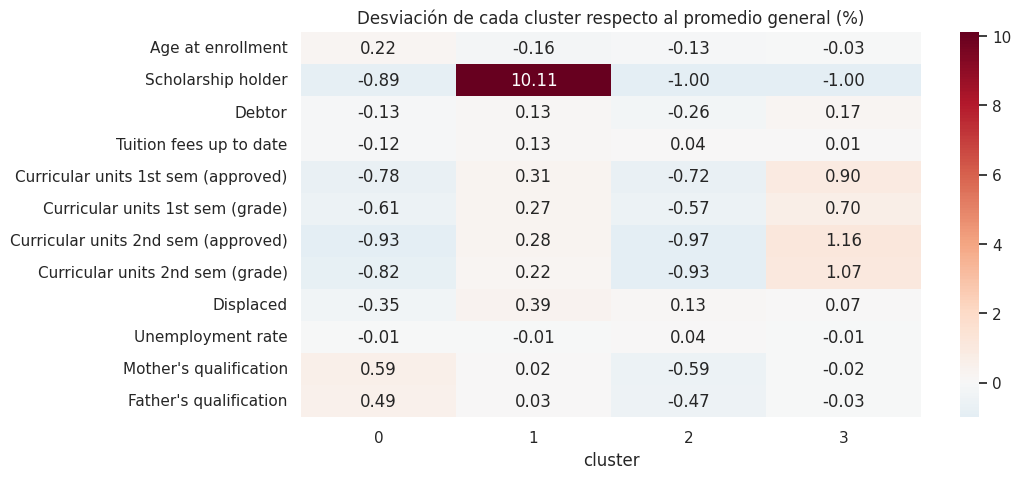

In [29]:
# Heatmap normalizado para visualizar rápidamente qué distingue a cada cluster
perfil_normalizado = (perfil_clusters.drop("Promedio general") - promedio_general) / promedio_general

plt.figure(figsize=(10,5))
sns.heatmap(perfil_normalizado.T, cmap="RdBu_r", center=0, annot=True, fmt=".2f")
plt.title("Desviación de cada cluster respecto al promedio general (%)")
plt.show()

In [30]:
# Tamaño de cada cluster (para saber cuántos alumnos representa cada perfil)
tamano_clusters = en_riesgo["cluster"].value_counts().sort_index()
print(tamano_clusters)

# --- IMPORTANTE ---
# Aquí es donde tú, con criterio humano, nombras cada cluster mirando el heatmap anterior.
# Ejemplo (ajusta según lo que realmente veas en tus resultados):
nombres_perfiles = {
    0: "Riesgo económico (deuda, sin beca, aranceles atrasados)",
    1: "Bajo rendimiento académico temprano",
    2: "Desconexión social / desplazados",
    3: "Perfil mixto de riesgo moderado"
}
en_riesgo["perfil"] = en_riesgo["cluster"].map(nombres_perfiles)
en_riesgo[["cluster","perfil"]].drop_duplicates()

cluster
0    366
1    125
2    353
3    559
Name: count, dtype: int64


,cluster,perfil
0,2,Desconexión social / desplazados
2,0,"Riesgo económico (deuda, sin beca, aranceles a..."
9,3,Perfil mixto de riesgo moderado
76,1,Bajo rendimiento académico temprano


### Clarificación de los perfiles de riesgo

Los nombres de los perfiles (`nombres_perfiles`) se asignan interpretando las características que más se desvían de la media general en el `heatmap` y en la tabla `perfil_clusters`.

**1. Perfil 0: 'Riesgo económico (deuda, sin beca, aranceles atrasados)'**
*   **Variables clave:** `Debtor`, `Tuition fees up to date`, `Scholarship holder`. Este grupo probablemente está conformado por estudiantes con dificultades financieras significativas, que no tienen becas y/o tienen aranceles pendientes, lo que los pone en riesgo de deserción.

**2. Perfil 1: 'Bajo rendimiento académico temprano'**
*   **Variables clave:** `Curricular units 1st sem (approved)`, `Curricular units 1st sem (grade)`, `Curricular units 2nd sem (approved)`, `Curricular units 2nd sem (grade)`. Este perfil agrupa a estudiantes que muestran un desempeño académico deficiente desde los primeros semestres, con pocas unidades aprobadas y bajas calificaciones, lo que los convierte en candidatos a desertar.

**3. Perfil 2: 'Desconexión social / desplazados'**
*   **Variables clave:** `Displaced`, `Age at enrollment`. Este nombre se basa en la observación de que estos estudiantes, en comparación con el promedio, tienen una mayor probabilidad de ser `Displaced` (desplazados de su lugar de origen) y, en el ejemplo, una `Age at enrollment` más elevada (aunque este último puede variar). La combinación de estar 'desplazado' (lo que podría implicar menor red de apoyo, dificultades de adaptación) y potencialmente una edad distinta al promedio de ingreso, sugiere un riesgo asociado a factores de integración social y adaptación al nuevo entorno universitario, más allá de lo puramente académico o económico.

**4. Perfil 3: 'Perfil mixto de riesgo moderado'**
*   **Variables clave:** `Combinación de factores académicos y socioeconómicos`. Este perfil se caracteriza por tener desviaciones de la media que no son tan extremas como en los otros clusters, o que muestran una mezcla de factores de riesgo académicos y socioeconómicos, pero con una intensidad 'moderada'. Es decir, no hay una única variable que domine su riesgo de forma abrumadora, sino que es una combinación de varios elementos que, en conjunto, generan un riesgo de deserción. A menudo, estos clusters 'mixtos' requieren una mirada más detallada a sus promedios para entender las particularidades de esa combinación.

## 9. Traducción a recomendaciones

Tabla resumen: perfil → variables clave → intervención sugerida. Esta tabla es el insumo directo para las casas estudiantiles.

In [31]:
# Plantilla de recomendaciones — completa la columna 'intervencion_sugerida'
# con base en lo que efectivamente observaste en el heatmap de la sección anterior
recomendaciones = pd.DataFrame({
    "perfil": list(nombres_perfiles.values()),
    "n_alumnos": tamano_clusters.values,
    "variables_clave": [
        "Debtor, Tuition fees up to date, Scholarship holder",
        "Curricular units 1st/2nd sem (approved, grade)",
        "Displaced, Age at enrollment",
        "Combinación de factores académicos y socioeconómicos"
    ],
    "intervencion_sugerida": [
        "Priorizar en programas de becas/ayudas y planes de pago flexibles",
        "Tutorías académicas tempranas y cursos de nivelación en 1er semestre",
        "Programas de integración social y mentoría entre pares",
        "Seguimiento personalizado combinando apoyo académico y económico"
    ]
})

recomendaciones

,perfil,n_alumnos,variables_clave,intervencion_sugerida
0,"Riesgo económico (deuda, sin beca, aranceles a...",366,"Debtor, Tuition fees up to date, Scholarship h...",Priorizar en programas de becas/ayudas y plane...
1,Bajo rendimiento académico temprano,125,"Curricular units 1st/2nd sem (approved, grade)",Tutorías académicas tempranas y cursos de nive...
2,Desconexión social / desplazados,353,"Displaced, Age at enrollment",Programas de integración social y mentoría ent...
3,Perfil mixto de riesgo moderado,559,Combinación de factores académicos y socioecon...,Seguimiento personalizado combinando apoyo aca...


## 10. Conclusiones y guardado de artefactos

Guardamos el modelo, el scaler y las tablas de resultados para poder usarlos después (ej. en una app o dashboard, o simplemente para anexarlos a la memoria).

In [32]:
joblib.dump(mejor_modelo, "modelo_riesgo_desercion.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(kmeans_final, "kmeans_perfiles.pkl")

recomendaciones.to_csv("recomendaciones_por_perfil.csv", index=False)
en_riesgo.to_csv("alumnos_en_riesgo_con_perfil.csv", index=False)

print("Artefactos guardados correctamente.")

Artefactos guardados correctamente.


### Próximos pasos sugeridos
- Ajustar `UMBRAL_RIESGO` y `K_OPTIMO` según los resultados reales que obtengas.
- Validar el modelo con técnicas de cross-validation (`StratifiedKFold`) para reportar métricas más robustas en la memoria.
- Documentar cada perfil con capturas del heatmap y estadísticas descriptivas para el informe final.
- Si el tiempo lo permite, comparar los perfiles obtenidos con clustering jerárquico como validación cruzada del método.